# EDA — Part 2: Histograms, Boxplots, Pairplots and Heatmaps

**Module 9: Exploratory Data Analysis (EDA)**

## Objectives of this learning
- Understand the difference between using charts to *present* data and using them to *explore* it
- Read histograms and interpret the shape of a distribution
- Use boxplots to compare groups and detect outliers at a multivariate scale
- Build and interpret pairplots to explore multiple variables at once
- Read and interpret correlation heatmaps

## Context
> *"A picture is worth a thousand words. But only if you know how to read it."*

In **Module 6** you learned how to create charts. The goal here is different: it is not about *making* pretty charts, but about using them as **tools to interrogate the data**. In EDA, every chart must answer a concrete question about the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# General style settings
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
np.random.seed(42)

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


In [ ]:
# Load the Superstore dataset — the same one used in Module 6
# Adjust the path to match your environment -WARNING: CHANGE THE PATH TO YOUR OWN
df = pd.read_csv('content/5-Data_Visualization_&_Storytelling/3-Visualization-best-practices/Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

---
## 1. The mindset shift: from visualising to exploring

In Module 6, the question was: *"How do I represent this data?"*

In EDA, the question is: *"What is this data telling me?"*

The practical difference:

| Visualisation (Module 6) | EDA (this module) |
|--------------------------|-------------------|
| Create a sales histogram | Is the sales distribution skewed? Why? |
| Make a boxplot by category | Which category has the most variability? Are there real outliers? |
| Choose the right chart type | Use multiple charts together to find patterns |
| Present results | Generate hypotheses to investigate |

---
## 2. Histograms in EDA: reading the shape of the distribution

You already know how to create histograms. In EDA, what matters is knowing how to **interpret** them.

### The four shapes you need to recognise

| Shape | What it means | What to do |
|-------|--------------|----------|
| **Normal / Symmetric** | Data is evenly distributed around the mean | The mean is representative |
| **Right-skewed** | Long tail towards high values. Most values are low. | The median is better than the mean |
| **Left-skewed** | Long tail towards low values. Most values are high. | Check whether there is an artificial upper bound |
| **Bimodal** | Two peaks. There may be two distinct mixed populations. | Investigate whether a hidden variable separates the groups |

###  Key question when reading a histogram
> *Does this distribution seem reasonable for this type of data? Is there anything unexpected?*

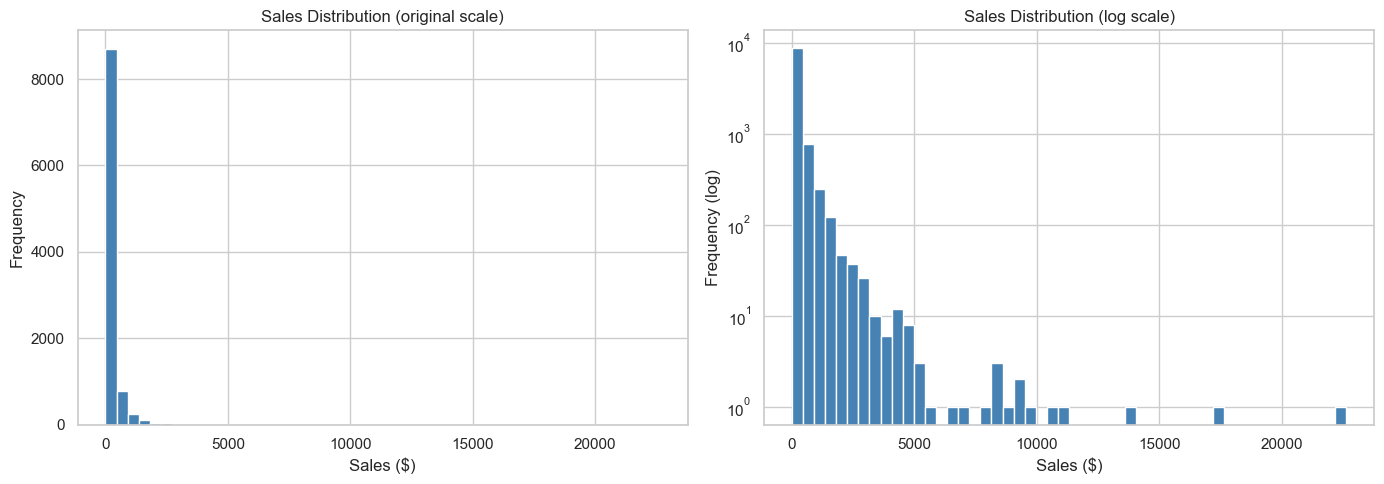

Media:   $229.86
Mediana: $54.49
Max:     $22638.48


In [24]:
# Explore the distribution of Sales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic histogram
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (original scale)')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

# Log-scale histogram — useful when there is heavy skew
axes[1].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white', log=True)
axes[1].set_title('Sales Distribution (log scale)')
axes[1].set_xlabel('Sales ($)')
axes[1].set_ylabel('Frequency (log)')

plt.tight_layout()
plt.show()

# Key statistics to interpret alongside the chart
print(f"Media:   ${df['Sales'].mean():.2f}")
print(f"Mediana: ${df['Sales'].median():.2f}")
print(f"Max:     ${df['Sales'].max():.2f}")

### What do we see here?

The distribution is **heavily right-skewed**: the vast majority of transactions are low-value, but there are some very large sales that stretch the tail.

Notice the difference between the **mean** and the **median**: the mean is much higher than the median because extreme values pull it upward. In this case, the median is more representative of the "typical" sale.

This is a very common pattern in sales data, salaries, house prices... whenever there is a natural lower bound (0) but no upper limit.

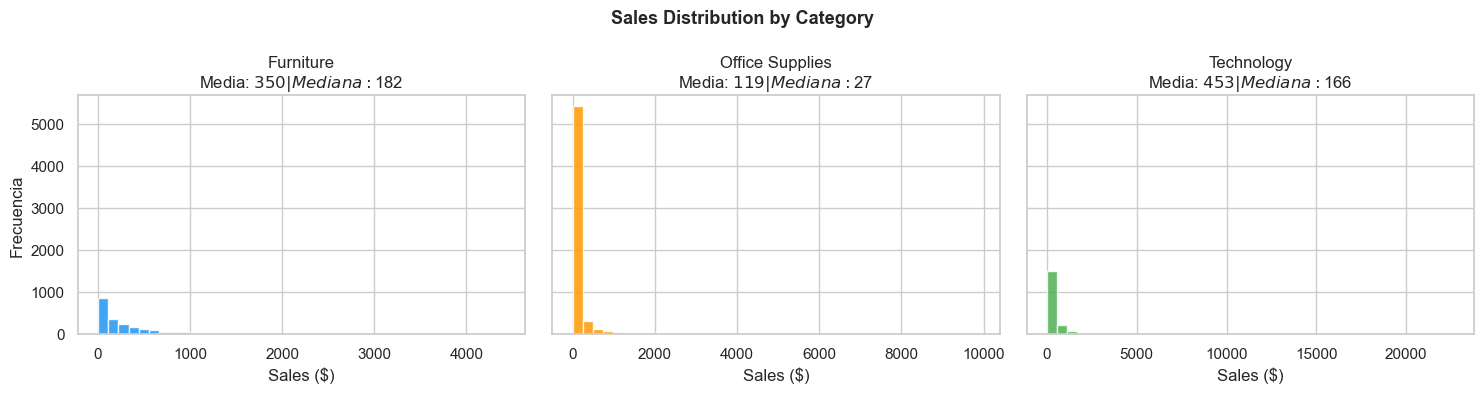

In [25]:
# Compare the Sales distribution by Category
# Question: Do the three categories have different distributions?

categories = df['Category'].unique()
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

colors = ['#2196F3', '#FF9800', '#4CAF50']

for i, (cat, color) in enumerate(zip(categories, colors)):
    subset = df[df['Category'] == cat]['Sales']
    axes[i].hist(subset, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{cat}\nMedia: ${subset.mean():.0f} | Mediana: ${subset.median():.0f}')
    axes[i].set_xlabel('Sales ($)')
    if i == 0:
        axes[i].set_ylabel('Frecuencia')

plt.suptitle('Sales Distribution by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 What do we see here?

All three categories show the same right-skew, but at different magnitudes. **Technology** has the longest tail — there are transactions with much higher values. **Office Supplies** has sales concentrated at the lowest values.

Using `sharey=True` lets us see scale differences between groups. Without it, each subplot would adjust its Y axis independently, and we would lose the comparison.

---
## 3. Boxplots en EDA: comparar grupos y detectar outliers

In Module 6 you saw that a boxplot shows median, quartiles and outliers. In EDA its real power lies in **comparing multiple groups at once**.

### Boxplot anatomy (quick reminder)

```
        ┌─────────────┐
  ──────┤     IQR     ├──────    ← Whiskers up to 1.5×IQR
        │      │      │
       Q1    Q2(med) Q3          ← The box contains the 50% central obs
        └─────────────┘



             ○  ○                ← Outside the Whiskers: outliers
```

### Questions that a boxplot helps you to answer
- Which group has the highest median?
- Which group is most variable (larger box)?
- Is there a group with many outliers?
- Are the distributions skewed (median not centred in the box)?

C:\Users\andre\AppData\Local\Temp\ipykernel_29552\1016651352.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\andre\AppData\Local\Temp\ipykernel_29552\1016651352.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


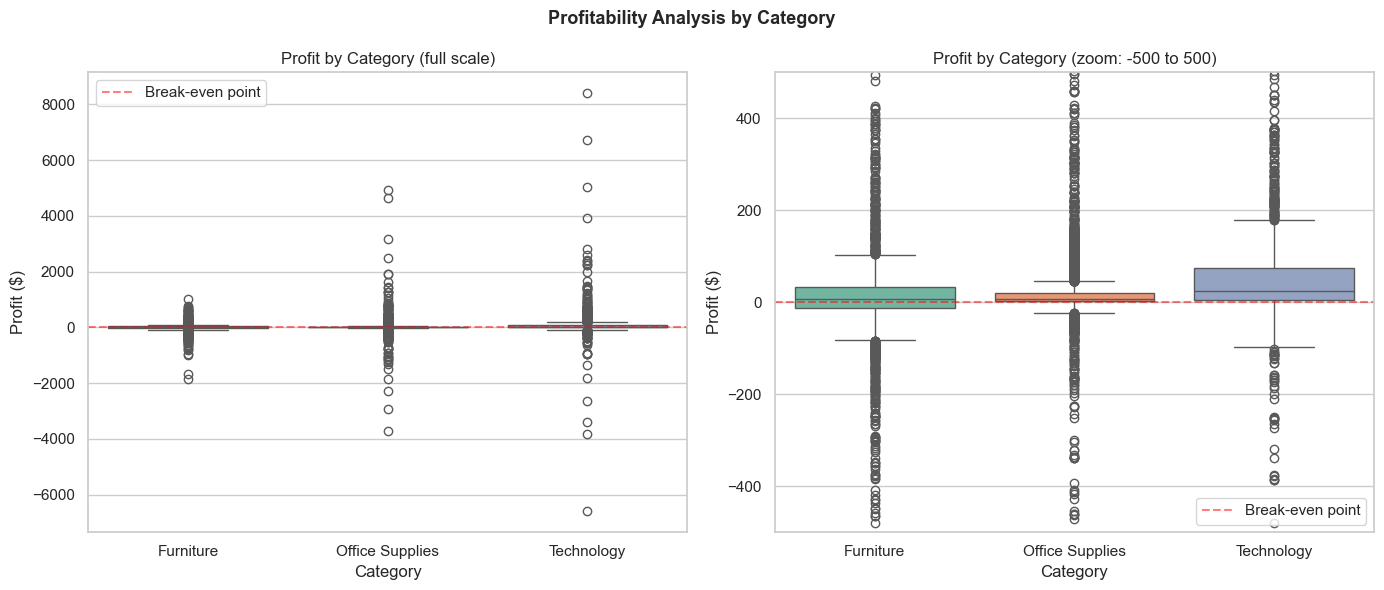

In [36]:
# Boxplot of Profit by Category
# Question: Which category is most profitable? And most variable?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Basic version
sns.boxplot(
    data=df,
    x='Category',
    y='Profit',
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Profit by Category (full scale)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Profit ($)')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Break-even point')
axes[0].legend()

# Zoomed version (excluding extreme outliers) to see the box more clearly
sns.boxplot(
    data=df,
    x='Category',
    y='Profit',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_ylim(-500, 500)  # Zoom in to see the boxes clearly
axes[1].set_title('Profit by Category (zoom: -500 to 500)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Break-even point')
axes[1].legend()

plt.suptitle('Profitability Analysis by Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###  What do we see here?

Several interesting things:

1. **Furniture** has the lowest median and many negative outliers — there are transactions with significant losses.
2. **Technology** has the highest median but also the greatest variability — tech sales can be very profitable or very bad.
3. **Office Supplies** is the most consistent category (smallest box).
4. The red break-even line shows that Furniture's median is very close to 0 — this category barely makes a profit on the typical sale.

**Warning note on outliers in the left chart**: the full scale makes the boxes almost invisible. When there are extreme outliers, it often helps to zoom in (as in the right chart) AND mention the outliers separately.

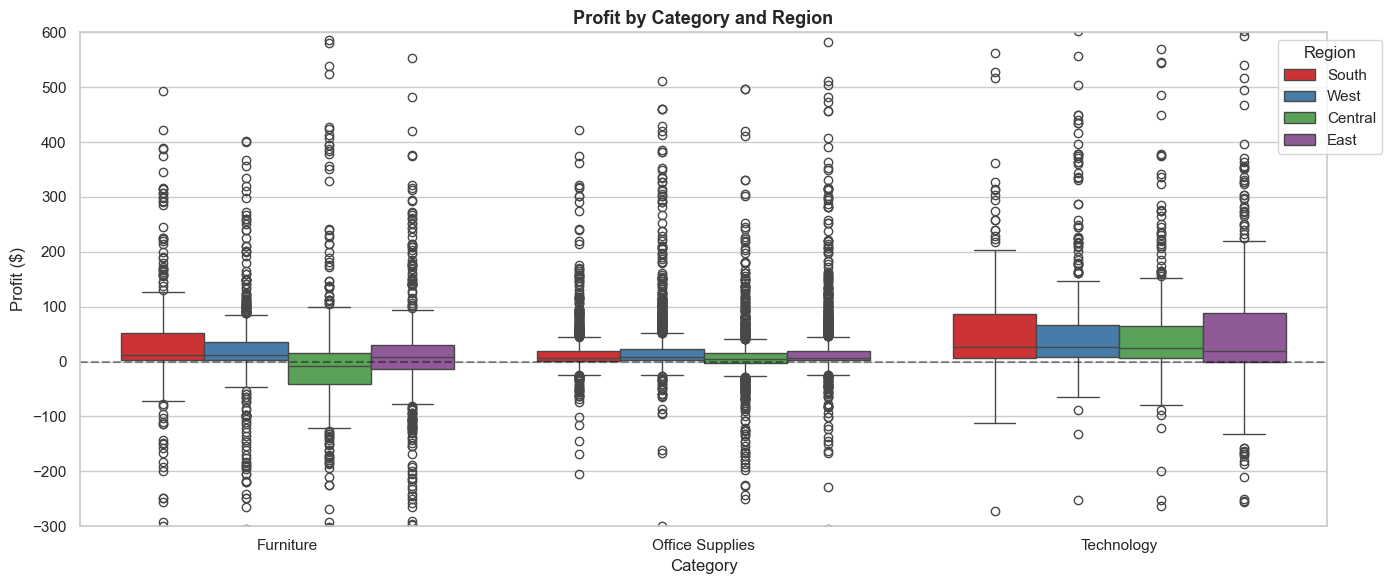

In [37]:
# Multidimensional boxplot: Profit by Region AND Category
# Question: Are there regional differences within each category?

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x='Category',
    y='Profit',
    hue='Region',
    palette='Set1'
)

plt.ylim(-300, 600)
plt.title('Profit by Category and Region', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### What do we see here?

The `hue='Region'` parameter lets us add an extra dimension without cluttering the chart. We can now see that **Furniture in the Central region** appears to have lower profitability than in other regions. This is a **hypothesis** that would need further investigation.

This is the spirit of EDA: the boxplot does not give us the answer, it tells us **where to look next**.

---
## 4. Pairplot: exploring multiple variables at a glance

A **pairplot** (or scatter matrix) shows all pairwise relationships between numerical variables in a dataset in a single figure. It is like making every possible scatter plot at once.

### What does it show?
- **Diagonal**: the distribution of each individual variable (histogram or KDE)
- **Off-diagonal cells**: scatter plot between each pair of variables

### When to use it?
- At the start of EDA, for a quick overview
- To identify which pairs of variables deserve deeper analysis
- To spot visible correlations, clusters or anomalous values

### ⚠️Important limitation
With many variables, the pairplot becomes unreadable. Use it with a **subset of relevant variables** (ideally no more than 5–6).

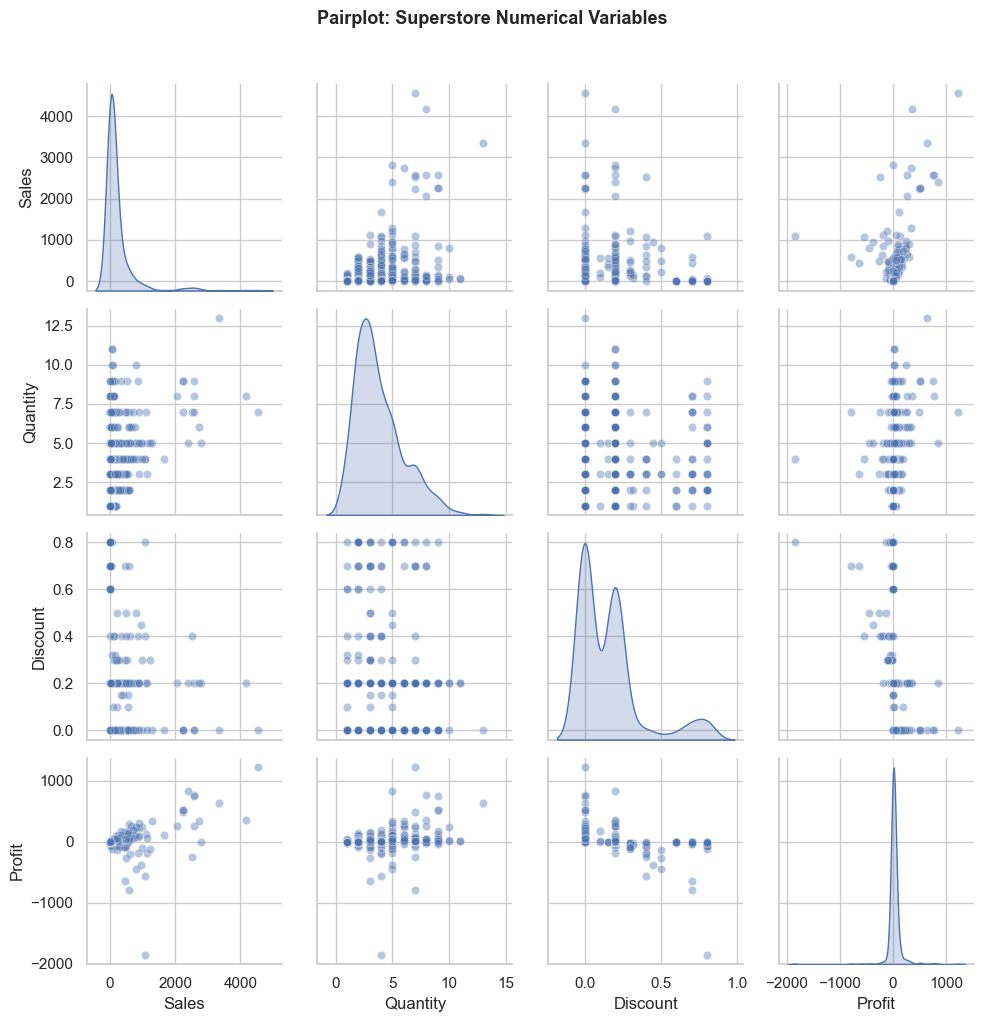

In [28]:
# Basic pairplot with Superstore numerical variables
# Using a sample to speed up rendering

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df_sample = df[numeric_cols].sample(500, random_state=42)

sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot: Superstore Numerical Variables', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

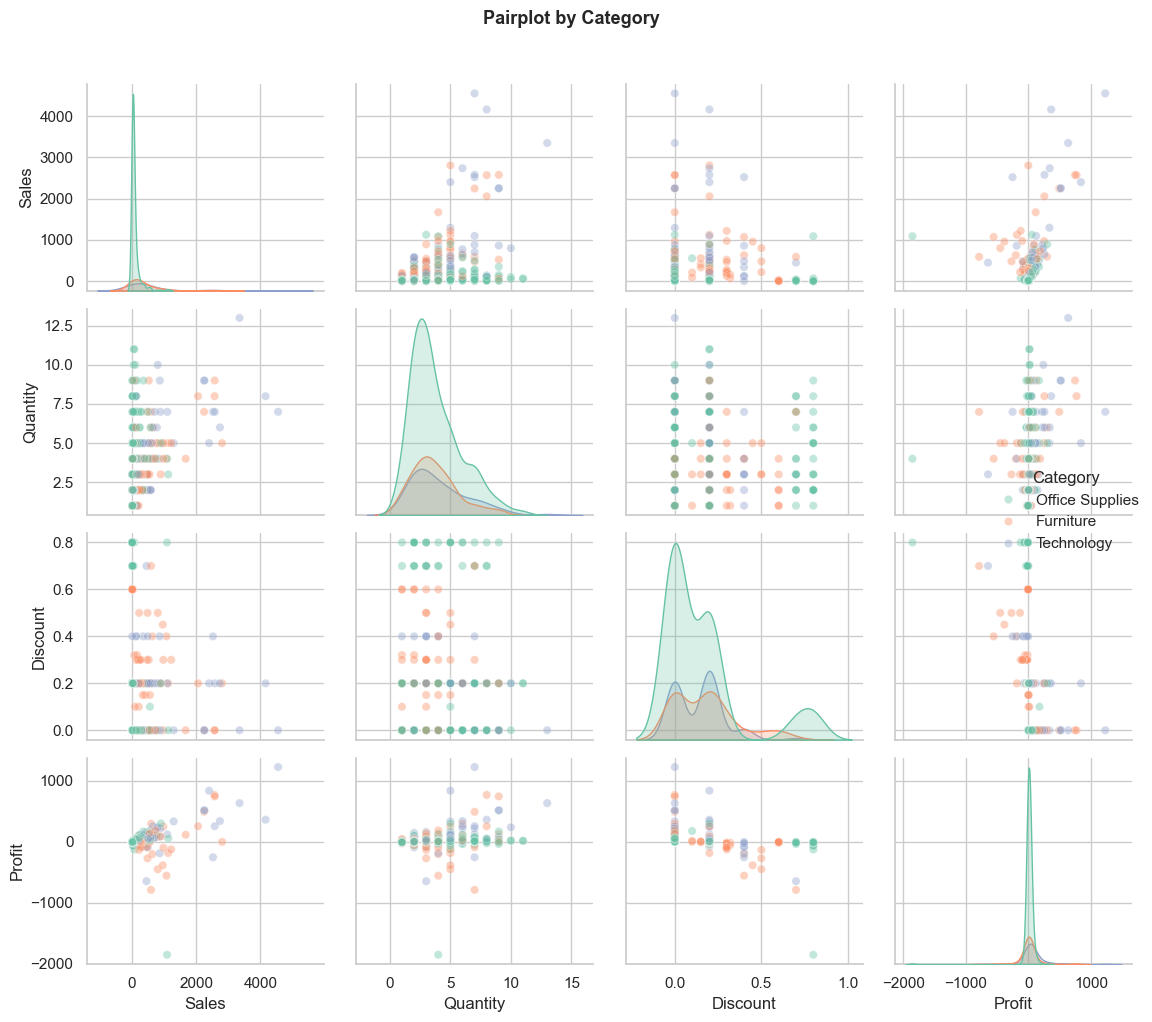

In [29]:
# Pairplot coloured by Category — adds a qualitative dimension

df_sample_cat = df[numeric_cols + ['Category']].sample(500, random_state=42)

sns.pairplot(
    df_sample_cat,
    hue='Category',
    diag_kind='kde',
    plot_kws={'alpha': 0.4},
    palette='Set2'
)
plt.suptitle('Pairplot by Category', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### What to look for in a pairplot?

Looking at the pairplot, we can ask ourselves:

1. **Do Sales and Profit have a linear relationship?** → They should, but the scatter shows a lot of dispersion. Why?
2. **Does Discount affect Profit?** → The Discount vs Profit scatter is very revealing in this dataset.
3. **Do the categories separate visually?** → In the diagonal (KDE) we can see whether Technology has a different sales distribution from Office Supplies.
4. **Are there cloud, line or fan-shaped patterns?** → A fan shape indicates that the variability of Y depends on the value of X (heteroscedasticity).

**Observation**: The Discount vs Profit scatter seems to show that higher discounts lead to lower profit — and sometimes losses. This would deserve deeper analysis.

---
## 5. Correlation heatmap: quantifying relationships

The pairplot gives us a visual overview. The **correlation heatmap** quantifies it.

### What is the Pearson correlation coefficient?

It is a number between **-1 and +1** that measures the strength and direction of the linear relationship between two variables:

| Value | Interpretation |
|-------|---------------|
| **+1** | Perfect positive correlation |
| **+0.7 to +1** | Strong positive correlation |
| **+0.3 to +0.7** | Moderate positive correlation |
| **-0.3 to +0.3** | Weak or no correlation |
| **-0.3 to -0.7** | Moderate negative correlation |
| **-0.7 to -1** | Strong negative correlation |
| **-1** | Perfect negative correlation |

### ⚠️ To take into account about EDA
> **Correlation does not imply causation.**
>
> The fact that two variables correlate does not mean one causes the other. There may be a third variable (confounding variable) explaining the relationship, or it could be pure coincidence.

In [30]:
# Compute the correlation matrix

numeric_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numeric_df.corr()

print('Correlation matrix:')
print(corr_matrix.round(3))

Correlation matrix:
          Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000


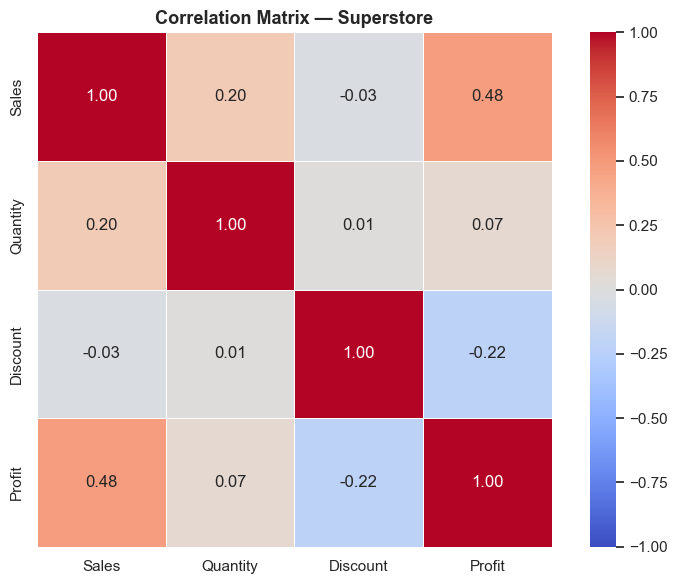

In [31]:
# Basic heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show numerical values
    fmt='.2f',           # Two decimal places
    cmap='coolwarm',     # Red = positive, Blue = negative
    vmin=-1, vmax=1,     # Fixed scale between -1 and 1
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Superstore', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### What do we see here?

The diagonal is always **1.0** — and represents the correlation between each variable with itself.

The most interesting findings:

1. **Discount vs Profit: negative correlation** — Higher discount, lower profit. Intuition confirmed quantitatively.
2. **Sales vs Profit: moderate positive correlation** — Selling more tends to generate more profit, but the relationship is not perfect (discounts distort it).
3. **Quantity vs Sales: positive correlation** — More units → more sales. Logical.

### How to read the heatmap?
- **Deep red** → strong positive correlation
- **Deep blue** → strong negative correlation
- **White / grey** → little or no correlation
- The matrix is **symmetric** — the value for Sales vs Profit equals Profit vs Sales

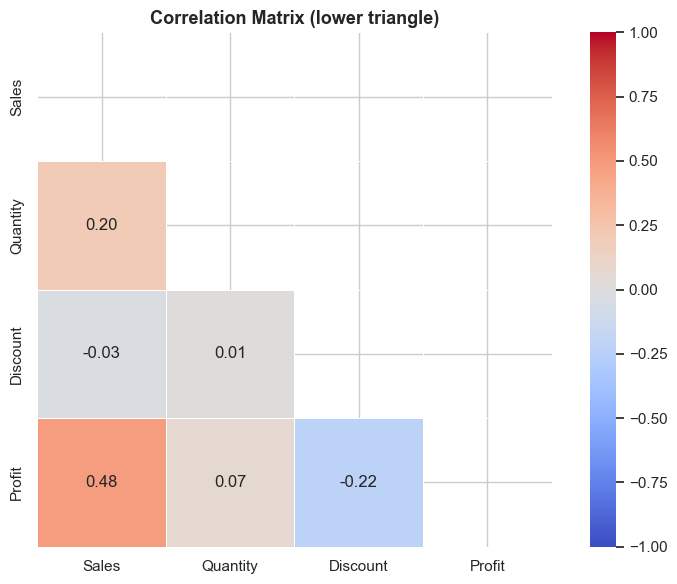

In [32]:
# Improved heatmap: lower triangle only (avoids duplicates)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    mask=mask,           # Hide the upper triangle (duplicate)
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix (lower triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Combining the tools: a real EDA workflow

In practice, these tools are used together and in sequence. The typical workflow is:

```
1. Histograms      → How is each variable distributed? Is there skew?
        ↓
2. Boxplots        → Are there differences between groups? Outliers?
        ↓
3. Pairplot        → Which pairs of variables seem related?
        ↓
4. Heatmap         → How strong is that relationship? In which direction?
        ↓
5. Hypotheses      → What deeper questions should I investigate?
```

Let us apply this workflow to the question:

### What factors influence profitability (Profit) in the Superstore?

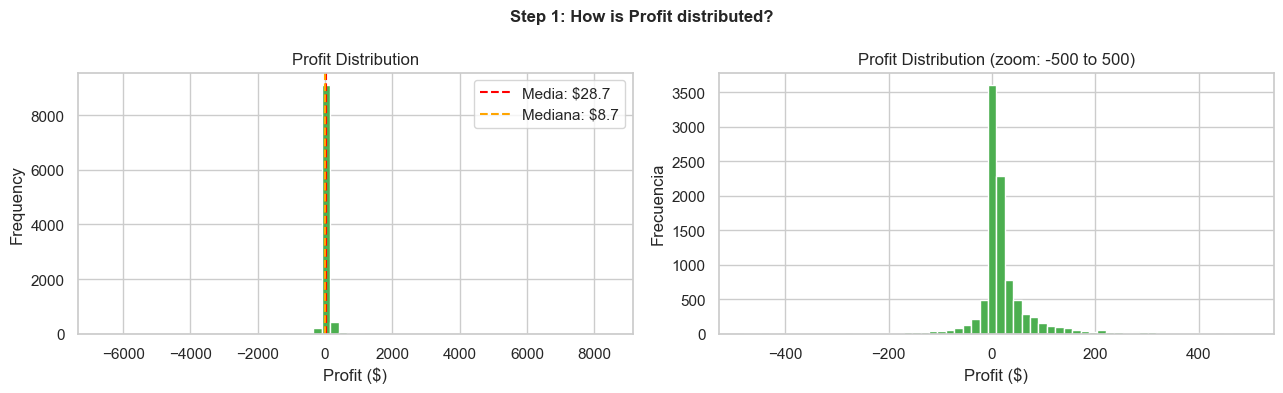

Loss-making transactions: 18.7%


In [33]:
# Step 1: Profit histogram — how is it distributed?

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Profit'], bins=60, color='#4CAF50', edgecolor='white')
axes[0].axvline(df['Profit'].mean(), color='red', linestyle='--', label=f'Media: ${df["Profit"].mean():.1f}')
axes[0].axvline(df['Profit'].median(), color='orange', linestyle='--', label=f'Mediana: ${df["Profit"].median():.1f}')
axes[0].set_title('Profit Distribution')
axes[0].set_xlabel('Profit ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Zoom in on the central range
axes[1].hist(df[df['Profit'].between(-500, 500)]['Profit'], bins=60, color='#4CAF50', edgecolor='white')
axes[1].set_title('Profit Distribution (zoom: -500 to 500)')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Step 1: How is Profit distributed?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

pct_negative = (df['Profit'] < 0).mean() * 100
print(f'Loss-making transactions: {pct_negative:.1f}%')

C:\Users\andre\AppData\Local\Temp\ipykernel_29552\3368202543.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='Set2', ax=axes[0])
C:\Users\andre\AppData\Local\Temp\ipykernel_29552\3368202543.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segment', y='Profit', palette='Set1', ax=axes[1])


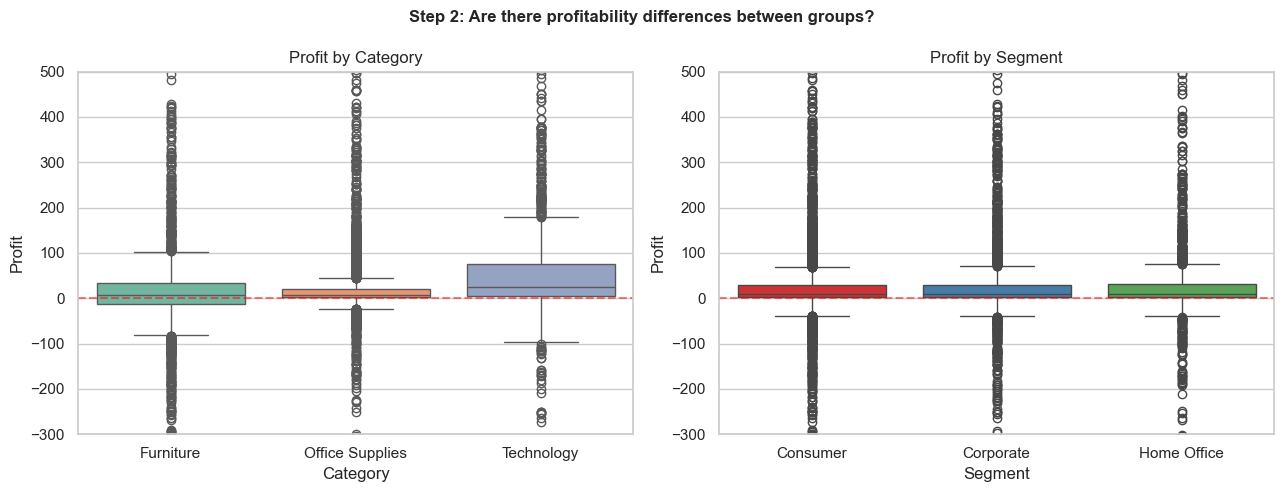

In [34]:
# Step 2: Boxplots — does Profit vary by category and segment?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='Category', y='Profit', palette='Set2', ax=axes[0])
axes[0].set_ylim(-300, 500)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Profit by Category')

sns.boxplot(data=df, x='Segment', y='Profit', palette='Set1', ax=axes[1])
axes[1].set_ylim(-300, 500)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Profit by Segment')

plt.suptitle('Step 2: Are there profitability differences between groups?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

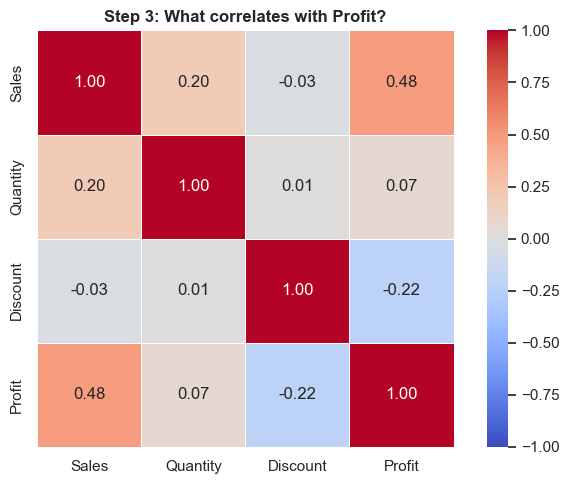

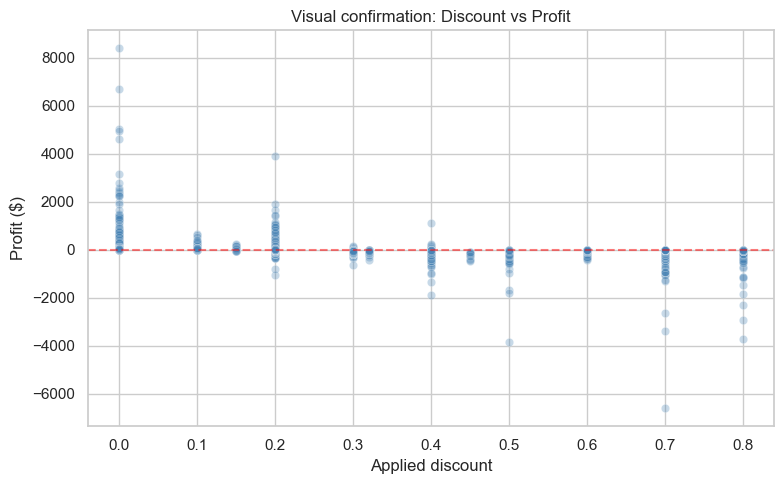

In [35]:
# Steps 3 & 4: Pairplot + Heatmap — which variables are related to Profit?

fig, axes = plt.subplots(1, 1, figsize=(7, 5))

corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes)
axes.set_title('Step 3: What correlates with Profit?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Visually confirm the most striking correlation: Discount vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.3, color='steelblue')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Visual confirmation: Discount vs Profit')
plt.xlabel('Applied discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

### Summary and conclusions


1. **~18% of transactions generate losses** — this is not a marginal figure.
2. **Furniture is the least profitable category**, with the lowest Profit median and many negative values.
3. **Discount is the main negative factor**: the higher the discount, the more likely the transaction is a loss.
4. **Possible hypotheses to investigate**: Are discounts in Furniture what explains its losses? Is there a region where the problem is especially severe?

These hypotheses lead us to the next topic of EDA

---
## 7. Summary and best practices

### When to use each tool

| Tool | Question it answers | When to use it |
|-------------|----------------------|---------------|
| **Histogram** | How is a variable distributed? | At the start, to understand each variable individually |
| **Boxplot** | How do groups compare? Are there outliers? | When you have categories and want to compare them |
| **Pairplot** | Which variables seem related? | For a quick overall view |
| **Heatmap** | How strong is that relationship? | To quantify and summarise correlations |

### ⚠️Common mistakes to avoid

1. **Confusing correlation with causation** — always the most important warning
2. **Ignoring the scale** — two distributions can look the same with different axes
3. **Pairplots with too many variables** — it becomes unreadable
4. **Assuming the heatmap tells the whole story** — a correlation of 0 does not mean independence, only the absence of a *linear* relationship
5. **Not filtering extreme outliers when making boxplots** — they can make the boxes invisible

### The ultimate goal of EDA

> It is not about making charts. It is about **finding hypotheses** that guide further researches and analysis.